X:
 [[1.4]
 [1.3]
 [1.5]
 [4.5]
 [4.1]
 [4.6]]
y:
 [0 0 0 1 1 1]


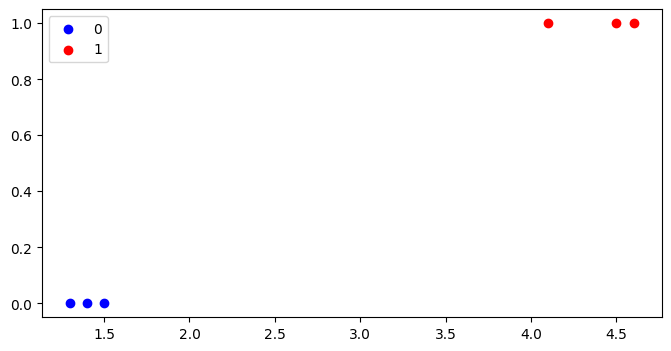

In [1]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_1D_2c.csv', dtype=None, delimiter=',', skip_header=1) 
X = iris[:, 0:1]
y = iris[:, 1]

# change data type
y = y.astype('uint8')

print('X:\n', X)
print('y:\n', y)

plt.figure(figsize=(8, 4))
plt.scatter(X[y == 0][:, 0], y[y == 0], color='b', label='0')
plt.scatter(X[y == 1][:, 0], y[y == 1], color='r', label='1')
plt.legend()
plt.show()

In [2]:
N = 6
k = 2

# one_hot
import numpy as np

def convert_one_hot(y, k):  
    one_hot = np.zeros((len(y), k))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

y_one_hot = convert_one_hot(y, k)
print(y_one_hot)

intercept = np.ones((X.shape[0], 1))
X = np.concatenate((intercept, X), axis=1)
print(X)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
[[1.  1.4]
 [1.  1.3]
 [1.  1.5]
 [1.  4.5]
 [1.  4.1]
 [1.  4.6]]


In [4]:
# some parameters
learning_rate = 0.1
losses = []
max_epoch = 100

# initialize parameters
theta = np.array([[0.1, 0.05], 
                  [0.2, -0.1]])
print('theta:\n', theta)

for epoch in range(max_epoch):
    # compute z
    z = X.dot(theta)    

    # compute y_hat
    exp_z = np.exp(z)    
    y_hat = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # compute the loss
    loss = -np.log(np.sum(y_hat*y_one_hot, axis=1))
    print(f'loss: {np.sum(loss)/N}')
    losses.append(np.sum(loss))

    # compute dtheta
    dz = y_hat - y_one_hot
    dtheta = X.T.dot(dz)/N

    # update
    theta = theta - learning_rate*dtheta

print(theta)

theta:
 [[ 0.1   0.05]
 [ 0.2  -0.1 ]]
loss: 1.0411729169458368
loss: 0.6952956441594199
loss: 0.6093988815156623
loss: 0.5856267464511231
loss: 0.5736913727950405
loss: 0.5647341588616567
loss: 0.5567268810167365
loss: 0.5491106341181343
loss: 0.541713509555752
loss: 0.5344783418974701
loss: 0.5273844539383535
loss: 0.520423277821687
loss: 0.5135903753474736
loss: 0.5068827444770362
loss: 0.500297892934351
loss: 0.4938335165053305
loss: 0.48748738737477887
loss: 0.48125731604476424
loss: 0.4751411390861344
loss: 0.4691367158946889
loss: 0.4632419285056746
loss: 0.45745468237254805
loss: 0.4517729073822094
loss: 0.446194558861899
loss: 0.44071761850180247
loss: 0.4353400951749673
loss: 0.4300600256547365
loss: 0.42487547523520613
loss: 0.419784538261214
loss: 0.4147853385741252
loss: 0.4098760298791882
loss: 0.4050547960397752
loss: 0.4003198513034442
loss: 0.39566944046445357
loss: 0.3911018389671092
loss: 0.3866153529541097
loss: 0.3822083192638516
loss: 0.37787910538047714
loss: 0.3

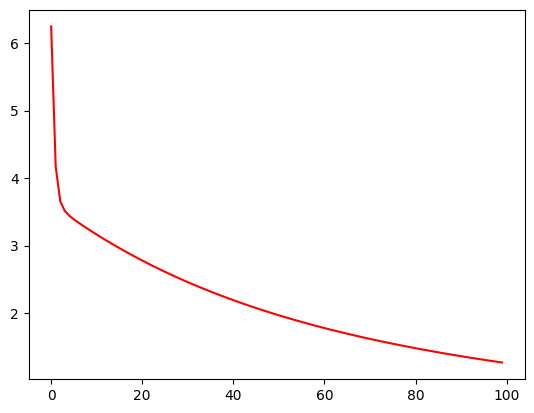

In [5]:
x_axis = range(len(losses))
plt.plot(x_axis, losses, color="r")
plt.show()

In [6]:
print(theta)

[[ 1.32599518 -1.17599518]
 [-0.48677014  0.58677014]]


In [7]:
z = X.dot(theta)    
exp_z = np.exp(z)
y_hat = exp_z / np.sum(exp_z, axis=1, keepdims=True)
print(y_hat)

[[0.7308686  0.2691314 ]
 [0.75145511 0.24854489]
 [0.70923673 0.29076327]
 [0.08875428 0.91124572]
 [0.13016227 0.86983773]
 [0.08044657 0.91955343]]


In [8]:
predicted_class = np.argmax(y_hat, axis=1)
print(predicted_class)

[0 0 0 1 1 1]
